# Anastruct Truss Analysis

Analyzing a simply supported truss at (0,4) and (18,5)
- 18 panels (creating vertical web members)
- Diagonal web members for stabilization
- Truss depth = 0.6m
- Loaded with a 2.4 kN/m UDL on the top chord


In [1]:
from anastruct import SystemElements

ss = SystemElements()

# Truss parameters
L = 18.0
dy = 1.0 # difference in y from x=0 to x=18
depth = 0.6
N = 18 # number of panels
dx = L / N
dy_per_panel = dy / N

# Create nodes and elements
# Bottom chord
for i in range(N):
    x1, y1 = i * dx, 4 + i * dy_per_panel
    x2, y2 = (i + 1) * dx, 4 + (i + 1) * dy_per_panel
    ss.add_truss_element(location=[[x1, y1], [x2, y2]])

# Top chord
for i in range(N):
    x1, y1 = i * dx, 4 + depth + i * dy_per_panel
    x2, y2 = (i + 1) * dx, 4 + depth + (i + 1) * dy_per_panel
    ss.add_truss_element(location=[[x1, y1], [x2, y2]])

# Vertical web members
for i in range(N + 1):
    x, y_bottom = i * dx, 4 + i * dy_per_panel
    y_top = y_bottom + depth
    ss.add_truss_element(location=[[x, y_bottom], [x, y_top]])

# Diagonal web members
for i in range(N):
    x1, y_bottom = i * dx, 4 + i * dy_per_panel
    x2, y_top2 = (i + 1) * dx, 4 + depth + (i + 1) * dy_per_panel
    ss.add_truss_element(location=[[x1, y_bottom], [x2, y_top2]])

# Supported at (0,4) and (18,5)
node_support_1 = ss.find_node_id([0, 4])
node_support_2 = ss.find_node_id([18, 5])

# Hinged support at (0,4)
ss.add_support_hinged(node_id=node_support_1)
# Rolling support at (18,5) restricting vertical translation (direction=2)
ss.add_support_roll(node_id=node_support_2, direction=2)

# Apply 2.4 kN/m UDL (Uniformly Distributed Load) on the top chord elements
# The top chord elements are added after the bottom chord elements, so their IDs are N+1 to 2N
for i in range(N + 1, 2 * N + 1):
    # Apply downward load (negative Y direction)
    ss.q_load(q=-2.4, element_id=i, direction='y')

# Solve the system
ss.solve()


array([ 0.00000000e+00,  0.00000000e+00, -1.37398465e+00,  1.47221653e-02,
        2.23947611e-01,  2.28468316e-02,  3.09868367e-02,  4.39435837e-01,
       -2.36428099e-01,  4.81528250e-02,  6.39756751e-01, -1.85184046e-01,
        6.56290468e-02,  8.19096934e-01, -1.63757059e-01,  8.28737223e-02,
        9.72537186e-01, -1.36230734e-01,  9.93950877e-02,  1.09605280e+00,
       -1.04917901e-01,  1.14750800e-01,  1.18651343e+00, -7.09496363e-02,
        1.28548413e-01,  1.24168311e+00, -3.52196149e-02,  1.40445023e-01,
        1.26022026e+00,  1.37076866e-03,  1.50147489e-01,  1.24167766e+00,
        3.79275943e-02,  1.57412339e-01,  1.18650265e+00,  7.35565307e-02,
        1.62045814e-01,  1.09603664e+00,  1.07363109e-01,  1.63903759e-01,
        9.72515746e-01,  1.38453054e-01,  1.62891869e-01,  8.19070184e-01,
        1.65931280e-01,  1.58965280e-01,  6.39724712e-01,  1.88910891e-01,
        1.52129132e-01,  4.39398448e-01,  2.06428329e-01,  1.42437891e-01,
        2.23904889e-01,  

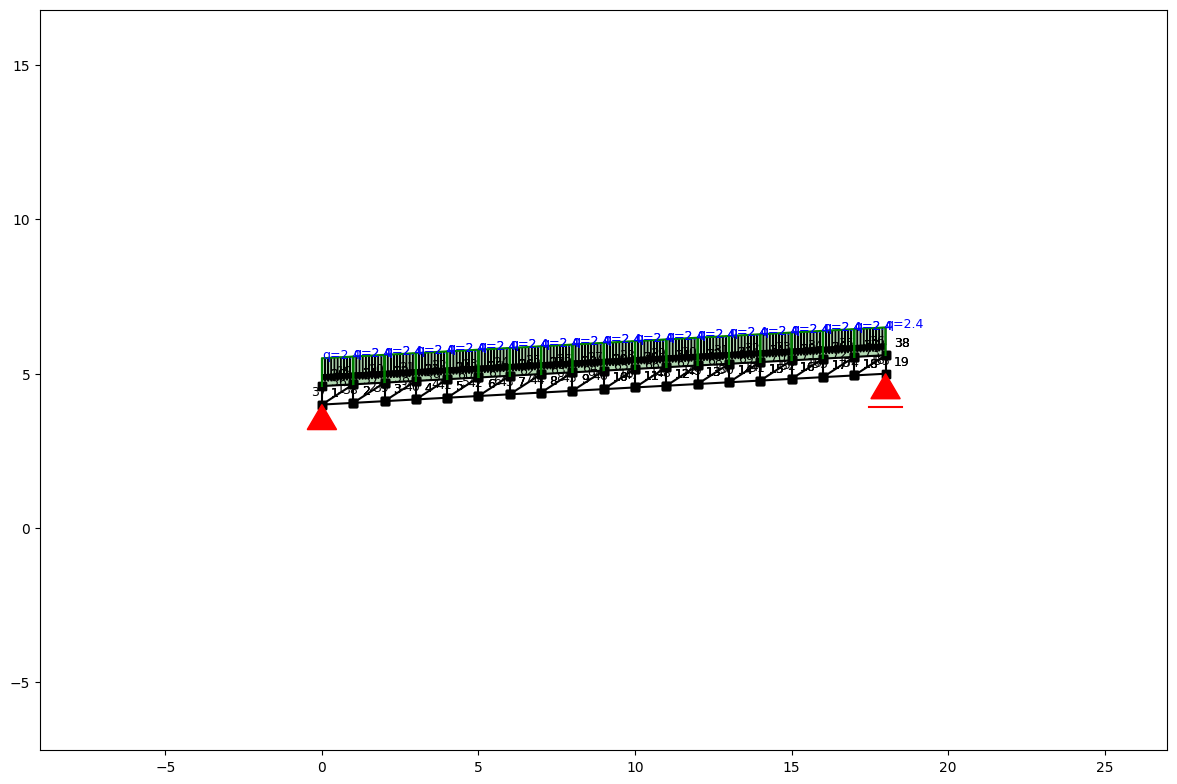

In [2]:
# Show the structure setup
# Note: we use show=True and matplotlib will display it inline in the notebook
fig = ss.show_structure(show=True)


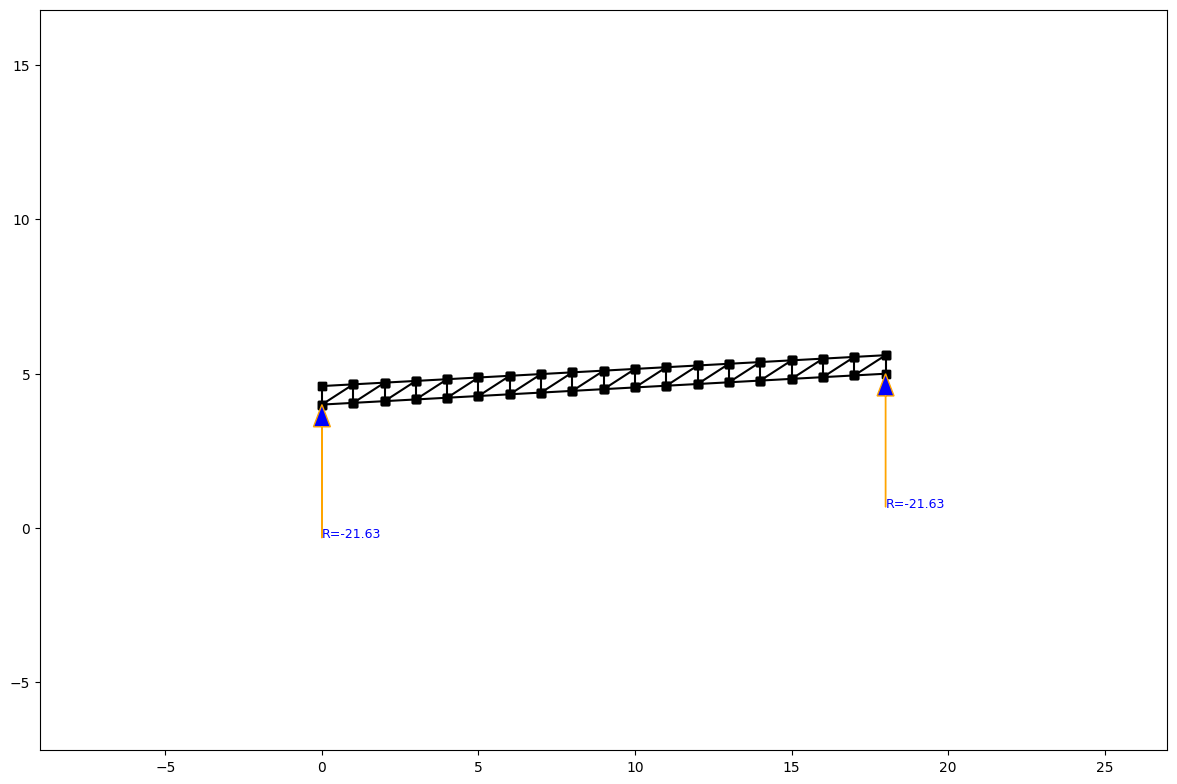

In [3]:
# Show reaction forces
fig = ss.show_reaction_force(show=True)


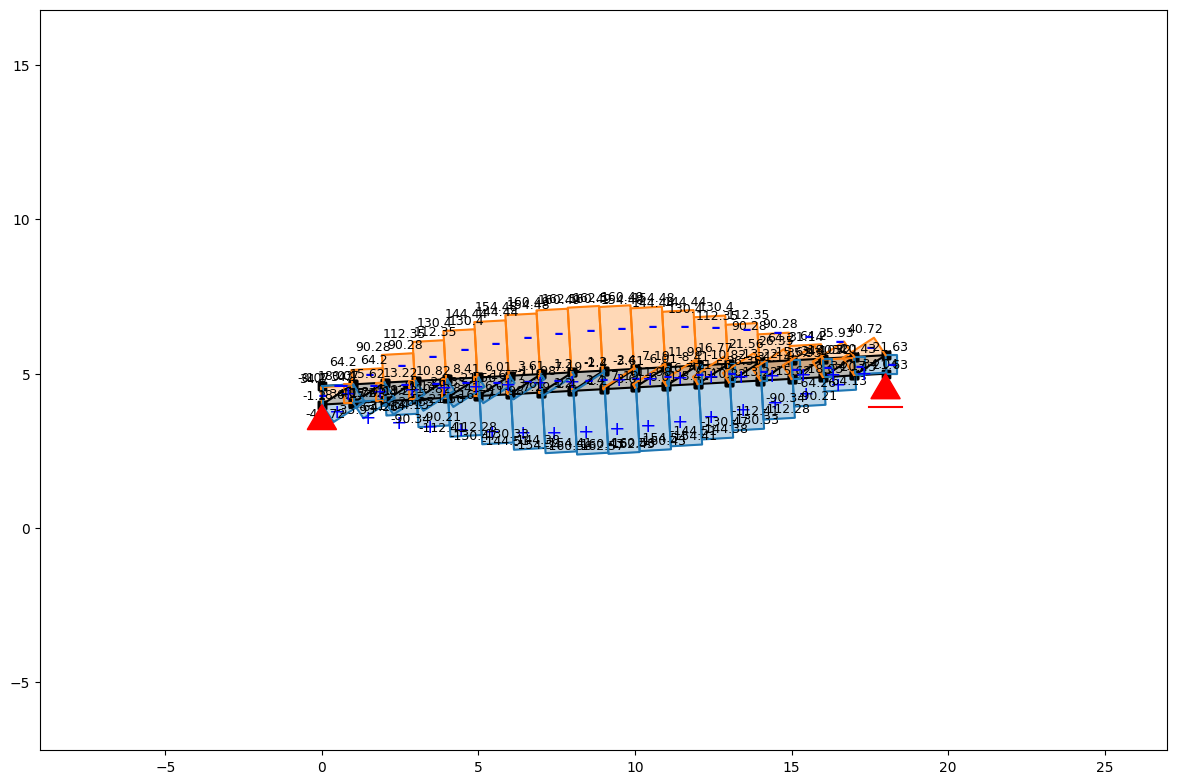

In [4]:
# Show axial forces
fig = ss.show_axial_force(show=True)


In [5]:
# Get internal forces and lengths for elements
# Axial forces (N) are in the element results, lengths are in element.l
# IDs 1 to 2N are chords, IDs 2N+1 to 4N+1 are webs
chord_forces = [ss.element_map[i].N_1 for i in range(1, 2 * N + 1)]
web_forces = [ss.element_map[i].N_1 for i in range(2 * N + 1, 4 * N + 2)]
chord_lengths = [ss.element_map[i].l for i in range(1, 2 * N + 1)]
web_lengths = [ss.element_map[i].l for i in range(2 * N + 1, 4 * N + 2)]

# Positive means tension, negative means compression in Anastruct
chord_max_tension = max(chord_forces) if any(f > 0 for f in chord_forces) else 0.0
chord_max_comp = min(chord_forces) if any(f < 0 for f in chord_forces) else 0.0
chord_max_length = max(chord_lengths) if chord_lengths else 0.0

web_max_tension = max(web_forces) if any(f > 0 for f in web_forces) else 0.0
web_max_comp = min(web_forces) if any(f < 0 for f in web_forces) else 0.0
web_max_length = max(web_lengths) if web_lengths else 0.0

# Print the summary
print("-" * 40)
print("TRUSS ANALYSIS SUMMARY")
print("-" * 40)
print("CHORDS:")
print(f"  Maximum Tension:      {chord_max_tension:^10.2f} kN")
print(f"  Maximum Compression:  {chord_max_comp:^10.2f} kN")
print(f"  Maximum Length:       {chord_max_length:^10.2f} m")
print("WEBS:")
print(f"  Maximum Tension:      {web_max_tension:^10.2f} kN")
print(f"  Maximum Compression:  {web_max_comp:^10.2f} kN")
print(f"  Maximum Length:       {web_max_length:^10.2f} m")
print("-" * 40)


----------------------------------------
TRUSS ANALYSIS SUMMARY
----------------------------------------
CHORDS:
  Maximum Tension:        162.50   kN
  Maximum Compression:   -162.57   kN
  Maximum Length:          1.00    m
WEBS:
  Maximum Tension:        40.72    kN
  Maximum Compression:    -40.72   kN
  Maximum Length:          1.20    m
----------------------------------------
